In [1]:
# This code works in Python 3.10.6
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
from typing import Dict, List, Union
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import IMDB
import random
import torch
import dgl
from torch import optim
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import torch.nn.functional as F
import torch_geometric.utils.convert
from torch_geometric.nn import HANConv
import seaborn as sns
from collections import Counter
import os
import glob
import warnings
warnings.filterwarnings('ignore')

Create Metagraph

In [2]:
dataset = IMDB(root='./imdb_data')
data = dataset[0]
print(data)

HeteroData(
  movie={
    x=[4278, 3066],
    y=[4278],
    train_mask=[4278],
    val_mask=[4278],
    test_mask=[4278],
  },
  director={ x=[2081, 3066] },
  actor={ x=[5257, 3066] },
  (movie, to, director)={ edge_index=[2, 4278] },
  (movie, to, actor)={ edge_index=[2, 12828] },
  (director, to, movie)={ edge_index=[2, 4278] },
  (actor, to, movie)={ edge_index=[2, 12828] }
)


In [3]:
#Create metagraph
g = torch_geometric.utils.convert.to_dgl(data)
meta_g= g.metagraph()

In [4]:
dataset = dataset = IMDB(root='./imdb_data')
data = dataset[0]
data

HeteroData(
  movie={
    x=[4278, 3066],
    y=[4278],
    train_mask=[4278],
    val_mask=[4278],
    test_mask=[4278],
  },
  director={ x=[2081, 3066] },
  actor={ x=[5257, 3066] },
  (movie, to, director)={ edge_index=[2, 4278] },
  (movie, to, actor)={ edge_index=[2, 12828] },
  (director, to, movie)={ edge_index=[2, 4278] },
  (actor, to, movie)={ edge_index=[2, 12828] }
)

Train IMDB

In [5]:
#https://github.com/pyg-team/pytorch_geometric/blob/master/examples/hetero/han_imdb.py

class HAN(nn.Module):
    def __init__(self, in_channels: Union[int, Dict[str, int]],
                 out_channels: int, hidden_channels=128, heads=8):
        super().__init__()
        self.han_conv = HANConv(in_channels, hidden_channels, heads=heads,
                                dropout=0.6, metadata=data.metadata())
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        out = self.han_conv(x_dict, edge_index_dict)
        out = self.lin(out['movie'])
        return out

def train() -> float:
    model.train()
    optimizer.zero_grad()
    out = model(data.x_dict, data.edge_index_dict)
    mask = data['movie'].train_mask
    loss = F.cross_entropy(out[mask], data['movie'].y[mask])
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def test() -> List[float]:
    model.eval()
    pred = model(data.x_dict, data.edge_index_dict).argmax(dim=-1)

    accs = []
    for split in ['train_mask', 'val_mask', 'test_mask']:
        mask = data['movie'][split]
        acc = (pred[mask] == data['movie'].y[mask]).sum() / mask.sum()
        accs.append(float(acc))
    return accs

In [6]:
def remap_indices(node_list):
    val_list = [*range(0, len(node_list), 1)]
    return dict(zip(node_list,val_list))  

In [7]:
def preprocess_edges(edgelist,node_list):
    res = [[node_list[i] for i, j in edgelist],[node_list[j] for i, j in edgelist]] 
    node_from = torch.tensor(res[0])
    node_to = torch.tensor(res[1])
    edges = torch.concat((node_from,node_to)).reshape(-1,len(node_from))
    return edges

In [8]:
def get_node_type(node_type):
    if node_type == 1:
        return 'actor'
    elif node_type == 0:
        return 'director'
    elif node_type == 2:
        return 'movie'


In [9]:
#List of edges in metagraph of IMDB
list(meta_g.edges())

[('actor', 'movie'),
 ('movie', 'actor'),
 ('movie', 'director'),
 ('director', 'movie')]

In [10]:
def create_dataset(nodes,edges,movie_df,director_df,actor_df,node_id,df_graph):
    movie = np.asarray(movie_df.drop(columns=['class']))
    director = np.asarray(director_df)
    actor = np.asarray(actor_df)
   
    x_movie = torch.tensor(movie).to(dtype=torch.float32)
    y_movie = torch.tensor(np.array(movie_df["class"]), dtype=torch.long)
    x_director = torch.tensor(director).to(dtype=torch.float32)
    x_actor = torch.tensor(actor).to(dtype=torch.float32)
    
    #Edges
    source,dest =list(map(list, zip(*edges)))

    movie_to_director = []
    director_to_movie = []
    movie_to_actor = []
    actor_to_movie = []
    remaining_edges = []

    class_dict = {'Director':0, 'Actor':1, 'Movie':2}

    for i in range(len(edges)):

        if (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Movie']) and \
        (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Director']):
                movie_to_director.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Director']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Movie']):
                director_to_movie.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Movie']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Actor']):
                movie_to_actor.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Actor']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Movie']):
                actor_to_movie.append((int(source[i]),int(dest[i])))

        else:
            #The edges not present in the metagraph  
            source_node_type = get_node_type(df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0])
            dest_node_type = get_node_type(df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0])
            remaining_edges.append((source_node_type,dest_node_type))
            #remaining_edges.append((int(source[i]),int(dest[i])))
            
    all_edges[node_id] = [*movie_to_director,*movie_to_actor,*director_to_movie,*actor_to_movie]
            
    movie = list(df_graph[df_graph['class'] == 2]['nodeId'])
    movie = [int(i) for i in movie]
    movie_nodes_mapping = remap_indices(movie)
    director = list(df_graph[df_graph['class'] == 0]['nodeId'])
    director = [int(i) for i in director]
    director_nodes_mapping = remap_indices(director)
    actor = list(df_graph[df_graph['class'] == 1]['nodeId'])
    actor = [int(i) for i in actor]
    actor_nodes_mapping = remap_indices(actor)


    node_list = {}
    for d in [movie_nodes_mapping, director_nodes_mapping, actor_nodes_mapping]:
        node_list.update(d)         

    #Create Hetero Data      
    small_graph = HeteroData({'movie':{'x': x_movie, 'y':y_movie}, 
                              'director':{'x': x_director},'actor':{'x': x_actor}})

    if movie_to_director:
        edge_index_movie_director = preprocess_edges(movie_to_director,node_list)
        small_graph['movie','to','director'].edge_index = edge_index_movie_director
        
    if director_to_movie:
        edge_index_director_movie = preprocess_edges(director_to_movie,node_list)
        small_graph['director','to','movie'].edge_index = edge_index_director_movie
    
    if actor_to_movie:
        edge_index_actor_movie = preprocess_edges(actor_to_movie,node_list)
        small_graph['actor','to','movie'].edge_index = edge_index_actor_movie
        
    if movie_to_actor:
        edge_index_movie_actor = preprocess_edges(movie_to_actor,node_list)
        small_graph['movie','to','actor'].edge_index = edge_index_movie_actor

    #Removing isolated nodes
    transform = T.Compose([T.remove_isolated_nodes.RemoveIsolatedNodes()])
    small_graph = transform(small_graph)
    #Adding test mask for prediction
    transform = T.RandomNodeSplit(split='train_rest', num_val=0.0, num_test=1.0)
    small_graph = transform(small_graph)
            
    return small_graph, remaining_edges

In [11]:
def evaluate_gnn(small_graph):
    with torch.no_grad():
        model.eval()
        #The pred is not used for accuracy, the softmax is used
        pred = model(small_graph.x_dict, small_graph.edge_index_dict).argmax(dim=-1)
        
        #Getting class prediction probabilities from the softmax layer
        softmax = model(small_graph.x_dict, small_graph.edge_index_dict).softmax(dim=-1)
        
        mask = small_graph['movie'].test_mask
        correct = (pred[mask] == small_graph['movie'].y[mask])
               
        correct_indices = [i for i, x in enumerate(correct.tolist()) if x]
        
        #Taking softmax values of the nodes for which prediction is correct
        softmax_pred_list = [softmax.tolist()[i] for i in correct_indices]

        
        return softmax_pred_list, correct_indices

In [12]:
def convert_to_discrete(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.5>=x<0.6 
                       else 2.0 if 0.6>=x<0.7 else 3.0 if 0.7>=x<0.8 else 4.0 if 0.8>=x<0.9 
                       else 5.0 if 0.9>=x<1.0 else 1.0)

In [13]:
# def get_real_graph(size):
#     real_graph = nx.Graph()
#     if(size <= 5):
#         real_graph = nx.read_gexf(real_graph_path+'real_G5.gexf')
#     elif(size <= 10):
#         real_graph = nx.read_gexf(real_graph_path+'real_G10.gexf')
#     elif(size <= 15):
#         real_graph = nx.read_gexf(real_graph_path+'real_G15.gexf')
#     elif(size <= 20):
#         real_graph = nx.read_gexf(real_graph_path+'real_G20.gexf')
#     elif(size <= 25):
#         real_graph = nx.read_gexf(real_graph_path+'real_G25.gexf')
#     elif(size <= 30):
#         real_graph = nx.read_gexf(real_graph_path+'real_G30.gexf')
#     elif(size <= 35):
#         real_graph = nx.read_gexf(real_graph_path+'real_G35.gexf')


#     return real_graph

In [14]:
print('Original no of graphs:',len([name for name in glob.glob('../../sampled_graphs_vae/imdb/*')]))

Original no of graphs: 1440


In [15]:
avg_max_pred_list = []
max_pred_list = []
graph_dict_list = []
softmax_dict_list = []
nodefeature_dict_list = []
all_edges_list = []
class_graphid_list = []

In [16]:
def get_max_pred(softmax_dict,i):
    #Getting the list of predictions for each class
    prob_class0_dict = {}
    prob_class1_dict = {}
    prob_class2_dict = {}
    
    for nodeid in softmax_dict:
        list0= []
        list1= []
        list2= [] 
        if len(softmax_dict[nodeid]) > 0:
            list0= []
            list1= []
            list2= []   
            for prob in softmax_dict[nodeid]:        
                list0.append(prob[0])        
                list1.append(prob[1]) 
                list2.append(prob[2]) 
    
    
         #Taking max probability of all nodes of each class in a graph
        if len(list0) != 0:
            prob_class0_dict[nodeid]=max(list0)
        if len(list1) != 0:
            prob_class1_dict[nodeid]=max(list1)
        if len(list2) != 0:
            prob_class2_dict[nodeid]=max(list2)
    
    max_pred0 = max(prob_class0_dict.values())
    max_pred1 = max(prob_class1_dict.values())
    max_pred2 = max(prob_class2_dict.values())
    
    print('Run'+str(i),max_pred0, max_pred1, max_pred2)
    max_pred_list.append([max_pred0, max_pred1, max_pred2])

    graph_dict_list.append(graph_dict)
    all_edges_list.append(all_edges)
    softmax_dict_list.append(softmax_dict)
    nodefeature_dict_list.append(nodefeature_dict)

    avg_max_pred = (max_pred0+max_pred1+max_pred2)/3
    avg_max_pred_list.append(avg_max_pred)
    
    class0_graphid = max(prob_class0_dict, key=prob_class0_dict.get)
    class1_graphid = max(prob_class1_dict, key=prob_class1_dict.get)
    class2_graphid = max(prob_class2_dict, key=prob_class2_dict.get)
    
    class_graphid_list.append([class0_graphid,class1_graphid,class2_graphid])

In [19]:
for i in range(0,10):
    counter=i
    model = HAN(in_channels=-1, out_channels=3)
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device = 'cpu'
    data, model = data.to(device), model.to(device)
    
    with torch.no_grad():  # Initialize lazy modules.
        out = model(data.x_dict, data.edge_index_dict)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.001)
    
    best_val_acc = 0
    start_patience = patience = 100
    for epoch in range(1, 700):  
        loss = train()
        train_acc, val_acc, test_acc = test()
        #if epoch%200==0:
            # print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, '
            #       f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')
    
        if best_val_acc <= val_acc:
            patience = start_patience
            best_val_acc = val_acc
        else:
            patience -= 1
    
        if patience <= 0:
            # print('Stopping training as validation accuracy did not improve '
            #       f'for {start_patience} epochs')
            break
    
    all_edges = {}
    softmax_dict = {}
    nodefeature_dict = {}
    graph_dict = {}
    rootdir = '../../sampled_graphs_vae/imdb/'
    
    #real_graph_path = '../../../approach_2/real_imdb_graphs/'
    dir_list = []
    for subdir, dirs,files in os.walk(rootdir):
        
        if files:
            graph_path = os.path.join(subdir, files[0])
            class_path = os.path.join(subdir, files[1])       
            feature_path = os.path.join(subdir, files[2])
            
            graph = nx.read_gexf(graph_path)
            filename = os.path.basename(graph_path)
            graph_id= filename.split('.')[0]
            #print(graph_id)
            
            nodeId_list = []
            
            for key, value in graph.nodes(data=True):
                nodeId_list.append(key)
                edges = [e for e in graph.edges]
                
            node_type_list = torch.load(class_path).detach().numpy()
            
            df_graph = pd.DataFrame()
            df_graph["nodeId"] = nodeId_list
            df_graph["class"] = node_type_list
            
            
            df_feature = pd.DataFrame(torch.load(feature_path).detach().numpy())        
            df_feature["class"] = node_type_list
            
            # real_graph = get_real_graph(len(nodeId_list))
            
            # node_label_list = []
            # for n in real_graph.nodes:
            #     node_type = real_graph.nodes[n]["type"] 
            #     if node_type == 2:
            #         node_class = real_graph.nodes[n]["class"]
            #         node_label_list.append(node_class)
                    
            
            movie_node_features = convert_to_discrete(df_feature[df_feature['class'] == 2].drop(['class'], axis = 1))
               
            #if node_label_list:
            labels = []
            #unique_labels = list(set(node_label_list))
            unique_labels = [0,1,2]
    
            for i in range(0,len(movie_node_features)):
                labels.append(random.choice(unique_labels))
                
            movie_node_features['class']= labels
    
            director_node_features = df_feature[df_feature['class'] == 0].drop(['class'], axis = 1)
            actor_node_features = df_feature[df_feature['class'] == 1].drop(['class'], axis = 1)
    
    
            small_graph_data, removed_edges = create_dataset(nodeId_list,edges,
                                    movie_node_features,director_node_features,
                                    actor_node_features,graph_id,df_graph)
        
            edge_list = all_edges[graph_id]
            graph = nx.Graph(edge_list)
            if not nx.is_empty(graph) and nx.is_connected(graph):
                
                    
                if (small_graph_data['movie'].x.nelement()!=0) and \
                (small_graph_data['actor','to','movie']) :

                    softmax, correct_indices = evaluate_gnn(small_graph_data)
                    softmax_dict[graph_id] = softmax
                    nodefeature_dict[graph_id]={'movie':small_graph_data['movie'].x[correct_indices],
                                            'director':small_graph_data['director'].x,
                                            'actor':small_graph_data['actor'].x}
                    graph_dict[graph_id]=df_graph
    
    print("No. of graphs evaluated: ",len(softmax_dict))

    get_max_pred(softmax_dict,counter)     
        

No. of graphs evaluated:  294
Run0 0.9985958933830261 0.9999997615814209 0.9994308352470398
No. of graphs evaluated:  294
Run1 0.9996850490570068 0.9999676942825317 0.999955415725708
No. of graphs evaluated:  294
Run2 0.9993545413017273 0.9999853372573853 0.9997394680976868
No. of graphs evaluated:  294
Run3 0.9966123700141907 0.9999940395355225 0.9987292885780334
No. of graphs evaluated:  294
Run4 0.9979573488235474 0.9999833106994629 0.9998798370361328
No. of graphs evaluated:  294
Run5 0.9998196959495544 0.9999967813491821 0.9997310042381287
No. of graphs evaluated:  294
Run6 0.9983495473861694 0.999996542930603 0.9998916387557983
No. of graphs evaluated:  294
Run7 0.9949563145637512 0.9999994039535522 0.9996616840362549
No. of graphs evaluated:  294
Run8 0.9992456436157227 0.9999996423721313 0.999982476234436
No. of graphs evaluated:  294
Run9 0.9994334578514099 0.9999853372573853 0.9987793564796448


In [20]:
avg_max_pred_list

[0.999342163403829,
 0.9998693863550822,
 0.9996931155522665,
 0.9984452327092489,
 0.9992734988530477,
 0.9998491605122884,
 0.9994125763575236,
 0.9982058008511862,
 0.99974258740743,
 0.9993993838628134]

In [21]:
np.mean(avg_max_pred_list)

0.9993232905864717

In [22]:
m = max(avg_max_pred_list)
index = avg_max_pred_list.index(m)
index

1

In [23]:
def plot_graph(graphid, max_pred,nodetype,edges,graph):

    classes = []
    G = nx.Graph(edges)
    df_graph = graph_dict[graphid]
    for g in G.nodes():
        #print(g)
        #print(df_graph.loc[g]['class'])
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0] == 0:
            classes.append(0)
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0] == 1:
            classes.append(1)
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0]== 2:
            classes.append(2)
   
    
    color_class_map = {0: 'blue', 1: 'red', 2: 'darkgreen'}
    
    nx.set_node_attributes(G, dict(zip(G.nodes(), classes)), 'class')
    
    print('Number of nodes: ',G.number_of_nodes())
    print('graph id: ',graphid)
    print(f'Max pred probability for class {nodetype} is {max_pred}')

    nx.draw(G, 
    with_labels=False, node_color=[color_class_map[node[1]['class']] 
                        for node in G.nodes(data=True)], 
            node_size=100,
        font_color='black')
    plt.show()

In [24]:
def index_2d(prob_list, v):
    for i, x in enumerate(prob_list):
        if v in x:
            return (i, x.index(v))

In [25]:
plt.rcParams.update({'axes.ymargin': 0.2})

In [26]:
def count_plot(feat_list):
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.countplot(x=0,ax=ax,data=pd.DataFrame(feat_list),width=0.3)
    for i in ax.containers:
        ax.bar_label(i,fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('feature values',fontsize=20)
    plt.ylabel('feature count',fontsize=20)

    plt.show()

In [27]:
class0_graphid = class_graphid_list[index][0]
class1_graphid = class_graphid_list[index][1]
class2_graphid = class_graphid_list[index][2]

In [28]:
max_pred0 = max_pred_list[index][0]
max_pred1 = max_pred_list[index][1]
max_pred2 = max_pred_list[index][2]

In [29]:
all_edges = all_edges_list[index]

In [30]:
graph_dict = graph_dict_list[index]

In [31]:
softmax_dict = softmax_dict_list[index]

In [32]:
nodefeature_dict = nodefeature_dict_list[index]

In [33]:
nodefeature_dict = nodefeature_dict_list[index]

 Plotting explanation graphs and node features for each class of Movie node
 
 Node colors:
 
 Director - Blue
 
 Actor - Red
 
 Movie - Darkgreen

Number of nodes:  5
graph id:  sync592127215643_G8
Max pred probability for class 0 is 0.9996850490570068


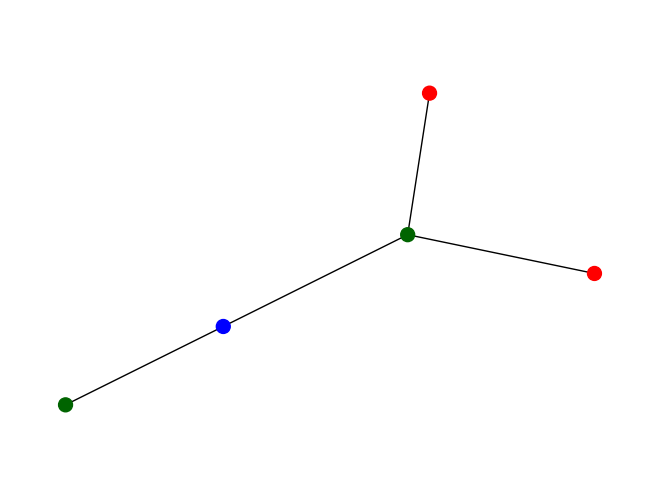

In [34]:
explanation_graph0 = plot_graph(class0_graphid, max_pred0, 0, all_edges[class0_graphid],graph_dict[class0_graphid])

In [35]:
ind= index_2d(softmax_dict[class0_graphid], max_pred0)[0]
list0= nodefeature_dict[class0_graphid]['movie'].numpy()[ind]
Counter(list0)

Counter({0.0: 3066})

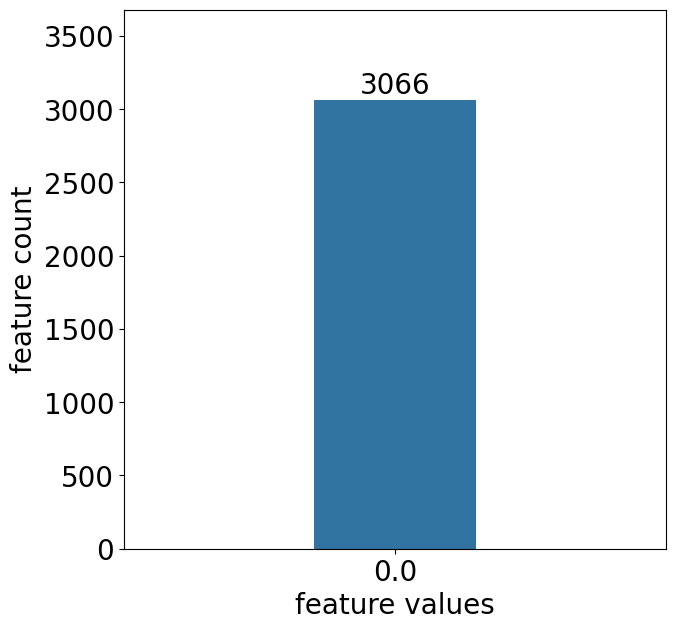

In [36]:
count_plot(list0)

Number of nodes:  3
graph id:  sync980509214212_G6
Max pred probability for class 1 is 0.9999676942825317


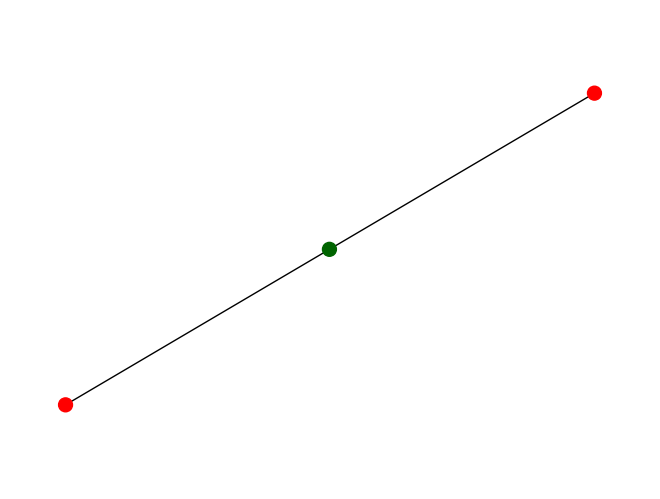

In [37]:
explanation_graph1 = plot_graph(class1_graphid, max_pred1, 1, all_edges[class1_graphid],graph_dict[class1_graphid])

In [38]:
ind= index_2d(softmax_dict[class1_graphid], max_pred1)[0]
list1= nodefeature_dict[class1_graphid]['movie'].numpy()[ind]
Counter(list1)

Counter({0.0: 3063, 2.0: 3})

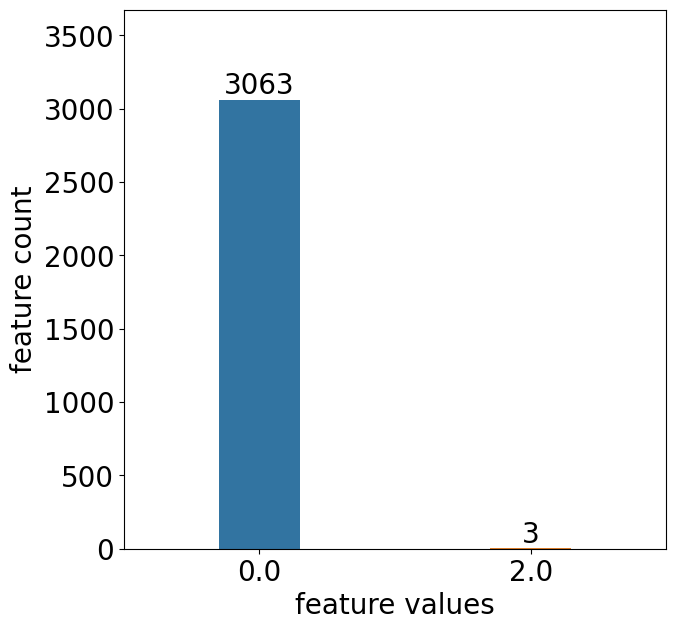

In [39]:
count_plot(list1)

Number of nodes:  2
graph id:  sync889743214159_G6
Max pred probability for class 2 is 0.999955415725708


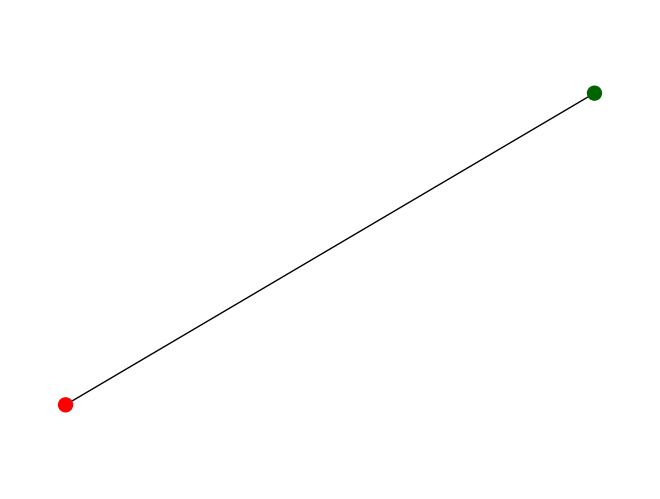

In [40]:
explanation_graph2 = plot_graph(class2_graphid, max_pred2, 2, all_edges[class2_graphid],graph_dict[class2_graphid])

In [41]:
ind= index_2d(softmax_dict[class2_graphid], max_pred2)[0]
list2= nodefeature_dict[class2_graphid]['movie'].numpy()[ind]
Counter(list2)

Counter({0.0: 3066})

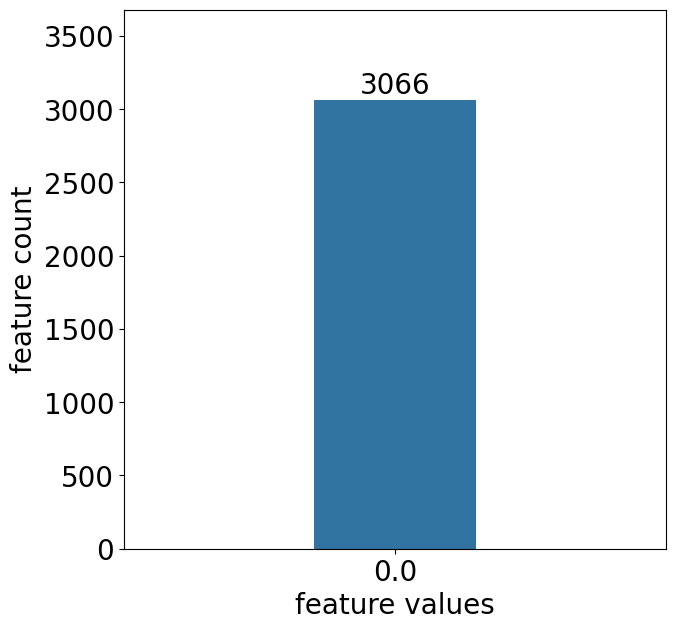

In [42]:
count_plot(list2)

In [43]:
def print_stat_cont_features(df):
    #print('summary',df.describe())
    print('mean',df.stack().mean())
    print('std dev',df.stack().std())

In [44]:
def plot_node_feat(imp_feat):
    sns.distplot(imp_feat,color= 'orange',hist= False)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Feature values',fontsize=20)
    plt.ylabel('Density',fontsize=20)

    plt.show() 

In [45]:
#Actor
actor0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['actor'].numpy())
print_stat_cont_features(actor0_df)

mean 0.0006119194
std dev 0.14554884


Text(0, 0.5, 'Density')

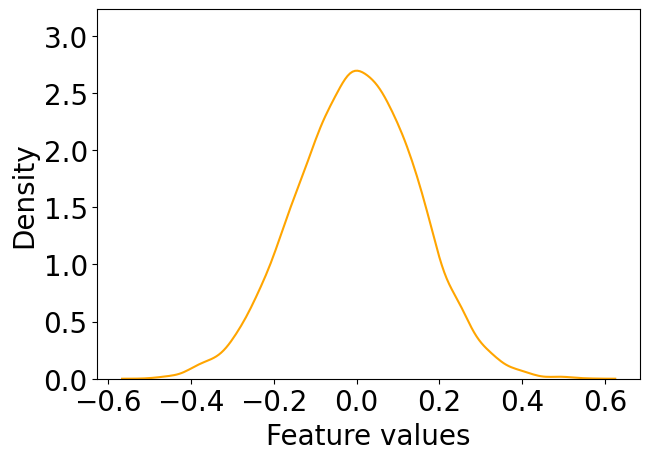

In [46]:
#plot_node_feat(actor0_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(actor0_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [47]:
actor1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['actor'].numpy())
print_stat_cont_features(actor1_df)

mean 0.0028560325
std dev 0.17499481


Text(0, 0.5, 'Density')

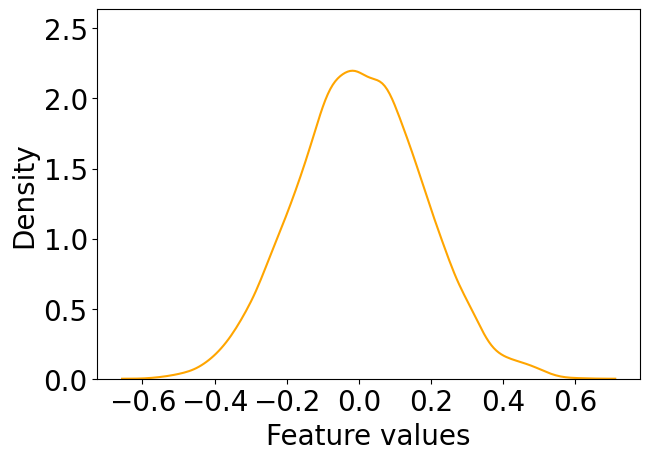

In [48]:
#plot_node_feat(actor1_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(actor1_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [49]:
actor2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['actor'].numpy())
print_stat_cont_features(actor2_df)

mean 0.0012345999
std dev 0.11844006


Text(0, 0.5, 'Density')

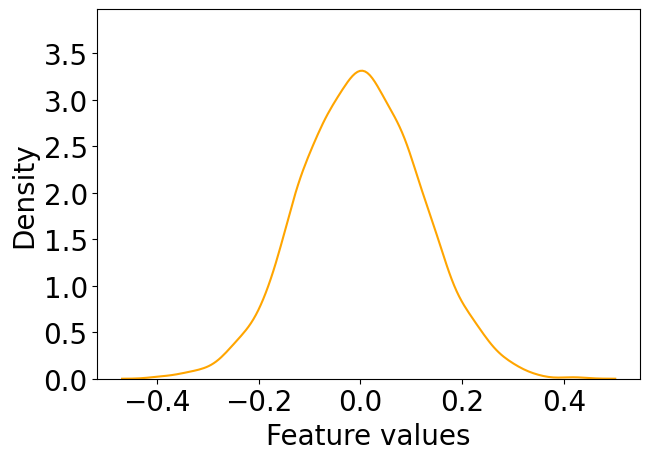

In [50]:
#plot_node_feat(actor2_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(actor2_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [51]:
#Director
# director0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['director'].numpy())
# print_stat_cont_features(director0_df)

In [52]:
#plot_node_feat(director0_df)

In [53]:
# director1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['director'].numpy())
# print_stat_cont_features(director1_df)

In [54]:
#plot_node_feat(director1_df)

## Edit distance

In [55]:
import itertools
import community as community_louvain
import matplotlib.cm as cm

def detect_community(G):
    partition = community_louvain.best_partition(G)

In [63]:
motifs_path = 'motif_pytorch_real/imdb_5to10/'
files_motif = os.listdir(motifs_path)

In [65]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/imdb_5to10/motif_real_10_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_4.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_4.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_4.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_4.

In [66]:
def get_avg_edit_distance(graphid_list):
    class_avg_edit_distance = []
    for graphid in graphid_list:
        #print(graphid)
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        detect_community(expln_graph)
        list_com= nx.community.louvain_communities(expln_graph, seed=123)
        H = expln_graph.subgraph(max(list_com, key=len))
        # nx.draw(G,with_labels=True)
        # plt.show()
        edit_dist_list = []       
        for index_m, file_m in enumerate(files_motif[:10]):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)
            edit_dist = nx.graph_edit_distance(H, motif_graph)
            #print(edit_dist)
            edit_dist_list.append(edit_dist)
        #print('class average', np.mean(edit_dist_list))
        class_avg_edit_distance.append(np.mean(edit_dist_list))
        
    return np.mean(class_avg_edit_distance) 

In [67]:
avg_edit_distance_list = []
for i in range(0,10):
    avg_edit_distance = get_avg_edit_distance(class_graphid_list[i])

    print('Run'+str(i),avg_edit_distance)
    avg_edit_distance_list.append(avg_edit_distance)
print(np.mean(avg_edit_distance_list))

Run0 2.0000000000000004
Run1 1.8666666666666665
Run2 2.0000000000000004
Run3 2.5333333333333337
Run4 2.4
Run5 2.5333333333333337
Run6 1.866666666666667
Run7 2.0000000000000004
Run8 2.066666666666667
Run9 2.5333333333333337
2.1800000000000006


## Fidelity

In [68]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/imdb_5to10/motif_real_10_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_10_4.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_5_4.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_6_4.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_0.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_1.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_2.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_3.gexf
motif_pytorch_real/imdb_5to10/motif_real_7_4.

In [69]:
def get_avg_fidelity(graphid_list):
    class_avg_fidelity = []
    for graphid in graphid_list:
        expln_graph = nx.Graph(all_edges[graphid])
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        # nx.draw(G,with_labels=True)
        # plt.show()
        fid_score_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)

            GM = nx.algorithms.isomorphism.GraphMatcher(expln_graph,motif_graph)
            x = 1 if GM.subgraph_is_isomorphic() else 0    
            fid_score_list.append(x)

        class_avg_fidelity.append(np.mean(fid_score_list))

    return np.mean(class_avg_fidelity) 

In [70]:
avg_fidelity_list = []

for i in range(0,10):
    avg_fidelity = get_avg_fidelity(class_graphid_list[i])

    print('Run'+str(i),avg_fidelity)
    avg_fidelity_list.append(avg_fidelity)
print(np.mean(avg_fidelity_list))

Run0 0.41111111111111115
Run1 0.4111111111111112
Run2 0.45555555555555555
Run3 0.3111111111111111
Run4 0.5888888888888889
Run5 0.2888888888888889
Run6 0.45555555555555555
Run7 0.45555555555555555
Run8 0.45555555555555555
Run9 0.3666666666666667
0.42000000000000004
